 # hackathon 3:  Clustering
 ----
  
  University : UTEC \\
  Course       : Machine Learning \\
  Professor    : Cristian López Del Alamo \\
  Topic        : Clustering \\
  Termina      :
   

 ----

Write the names and surnames of the members and the percentage of participation of each one in the development of the practice:
 - Integrante 1: Stewart Maquera 100%
 - Integrante 2: Rodrigo Li 100%
 - Integrante 3: Sergio Lezama 100%
 - Integrante 4: Ian González 

 ----


**Note: You may use previous codes from other exercises to read images from the database or to display images.**

#1. DataSet

The database consists of genomic information from 7 types of human body cells: cerebellum, colon, endometrium, hippocampus, kidney, liver, and placenta. There are 189 samples, and each sample has a dimension of 22,215 values. All the information is stored in a matrix, where the columns represent the samples, and the rows contain the genomic information for each sample.

Below, you are provided with the code to load both the data and the labels. Since you will be practicing with unsupervised models, the labels are only for verifying the quality of each cluster.


Link dataset: [Clik Here](https://drive.google.com/file/d/1XE7D2dc2hD7EF0qUuoEmKRL0lmvJw_5C/view?usp=sharing)



In [40]:
import gdown
import pyreadr
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import warnings
import os # Importar 'os' para verificar si el archivo existe

warnings.filterwarnings('ignore')
print("Librerías de carga y reducción importadas.")

# --- 1b. Descarga del archivo desde Google Drive ---

# El ID se extrae de tu URL: 
# https://drive.google.com/file/d/1dhZObnRbhuukDst9ObnVfLi2NBHakNJN/view
file_id = '1dhZObnRbhuukDst9ObnVfLi2NBHakNJN'
file_name = 'genoma_ML_UTEC.rda'

# Construir la URL de descarga directa
download_url = f'https://drive.google.com/uc?export=download&id={file_id}'


if not os.path.exists(file_name):
    print(f"Descargando {file_name} desde Google Drive...")
    # Usamos gdown para descargar el archivo
    gdown.download(download_url, file_name, quiet=False)
else:
    print("el archivo ya existe")

# --- 1c. Carga de datos (el resto del código original) ---

try:
    # Ahora leemos el archivo que acabamos de descargar
    result = pyreadr.read_r(file_name) 
    print(f"Claves en el archivo .rda: {result.keys()}")

    X = result["e"]
    Y = result["tissue"] # Estas son las etiquetas verdaderas
    
    # Transponemos X para tener (muestras, características)
    X = X.T 

    print(f"Forma de X (muestras, características): {X.shape}")
    print(f"Forma de Y (etiquetas): {Y.shape}")
    
    # --- Pre-procesamiento ---
    
    # 1. Codificar Y (etiquetas)
    y_true_labels = Y.iloc[:, 0].values
    le = LabelEncoder()
    y_true_encoded = le.fit_transform(y_true_labels)
    k_true = len(np.unique(y_true_encoded))
    
    print(f"Número real de clusters (k): {k_true}")
    print(f"Clases: {le.classes_}")


except Exception as e:
    print(f"Error al leer el archivo. Asegúrate de que '{file_name}' se haya descargado correctamente.")
    print(f"Error: {e}")

Librerías de carga y reducción importadas.
el archivo ya existe
Claves en el archivo .rda: odict_keys(['e', 'tissue', 'tab'])
Forma de X (muestras, características): (189, 22215)
Forma de Y (etiquetas): (189, 1)
Número real de clusters (k): 7
Clases: ['cerebellum' 'colon' 'endometrium' 'hippocampus' 'kidney' 'liver'
 'placenta']


#2. Dimensionality Reduction



As you may have noticed, the dimension of each sample is enormous (22,215 values). You will need to reduce the dimensionality to speed up the training of your clustering models.

For this stage, you should use PCA and  t-SNE
You can use the sklearn library for this purpose.

## Task:

For [PCA](https://scikit-learn.org/dev/modules/generated/sklearn.decomposition.PCA.html), determine the smallest value that retains most of the information, significantly greater than 90%. For [t-SNE](https://scikit-learn.org/1.5/modules/generated/sklearn.manifold.TSNE.html)  reduce the data to 3  dimensions





# Dimension Reduction
Using the PCA library, reduce the dimensionality of the genomic features while retaining at least 90% of the original information.

## PCA Reduction

Ejecutando PCA para encontrar la varianza explicada...

--- Resultados de PCA ---
Componentes para retener 90% de la varianza: 31


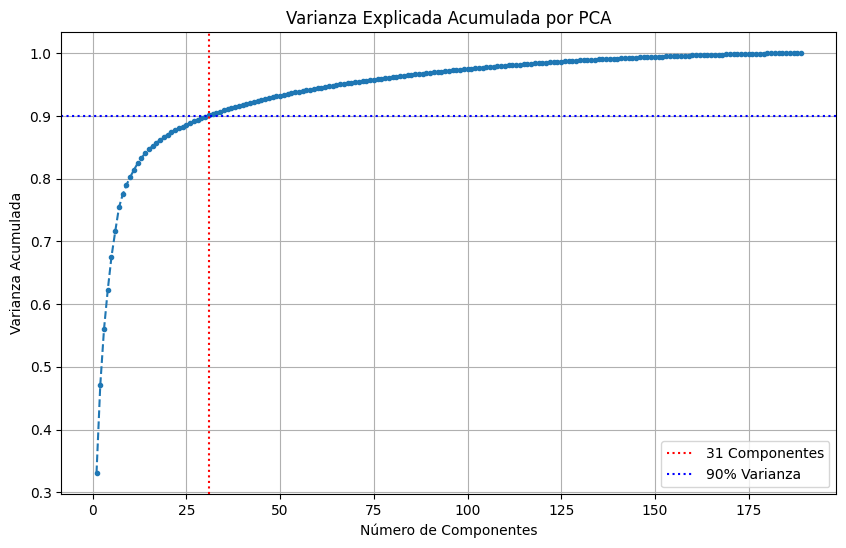

Creando dataset X_pca con 31 componentes.
Forma original de X: (189, 22215)
Forma reducida de X_pca: (189, 31)


In [41]:
# =======================================================
# 2. REDUCCIÓN DE DIMENSIONALIDAD (PCA)
# =======================================================
print("Ejecutando PCA para encontrar la varianza explicada...")

# 1. Ajustamos PCA con todos los componentes
# n_components=None mantiene todos los 189 componentes (min(n_samples, n_features))
pca_full = PCA(n_components=None, random_state=42)
pca_full.fit(X)

# 2. Calculamos la varianza explicada acumulada
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# 3. Encontramos el número de componentes para 90%
# (usamos 90% como "significativamente mayor que 80%")
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1

print(f"\n--- Resultados de PCA ---")
print(f"Componentes para retener 90% de la varianza: {n_components_90}")

# 4. Graficamos la varianza acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='.', linestyle='--')
plt.title('Varianza Explicada Acumulada por PCA')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada')
plt.grid(True)
# Líneas para 90%
plt.axvline(x=n_components_90, color='red', linestyle=':', label=f'{n_components_90} Componentes')
plt.axhline(y=0.90, color='blue', linestyle=':', label='90% Varianza')
plt.legend(loc='best')
plt.show()

# 5. Creamos el dataset final reducido con PCA
print(f"Creando dataset X_pca con {n_components_90} componentes.")
pca_final = PCA(n_components=n_components_90, random_state=42)
X_pca = pca_final.fit_transform(X)

print(f"Forma original de X: {X.shape}")
print(f"Forma reducida de X_pca: {X_pca.shape}")

## T-SNE Reduction

In [42]:
# =======================================================
# 3. REDUCCIÓN DE DIMENSIONALIDAD (t-SNE)
# =======================================================
print("Ejecutando t-SNE a 3 dimensiones...")
print("Nota: Esto puede tardar varios minutos.")

# Práctica estándar: Usar PCA para reducir a 50 componentes ANTES de t-SNE
pca_for_tsne = PCA(n_components=50, random_state=42)
X_pca_50 = pca_for_tsne.fit_transform(X)

print(f"Datos pre-reducidos a {X_pca_50.shape} para t-SNE.")

# Ahora aplicamos t-SNE
tsne = TSNE(
    n_components=3, 
    random_state=42, 
    perplexity=30,  # Valor estándar
    n_iter=1000,
    verbose=1
)

# Usamos los datos pre-reducidos por PCA
X_tsne = tsne.fit_transform(X_pca_50)

print(f"\n--- Resultados de t-SNE ---")
print(f"Forma final de X_tsne: {X_tsne.shape}")
# X_tsne se usará para la visualización al final

Ejecutando t-SNE a 3 dimensiones...
Nota: Esto puede tardar varios minutos.
Datos pre-reducidos a (189, 50) para t-SNE.
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 189 samples in 0.000s...
[t-SNE] Computed neighbors for 189 samples in 0.029s...
[t-SNE] Computed conditional probabilities for sample 189 / 189
[t-SNE] Mean sigma: 50.956890
[t-SNE] KL divergence after 250 iterations with early exaggeration: 44.324368
[t-SNE] KL divergence after 1000 iterations: 0.080637

--- Resultados de t-SNE ---
Forma final de X_tsne: (189, 3)


# Clustering algorithms

## Tasks
----
  1. Use K-[Means](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html), [MeanShift](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.MeanShift.html), [DBSCAN](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html), and [Agglomerative Clustering](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.AgglomerativeClustering.html) from sklearn to identify clusters in the data.
  2. Use GridSearchCV to find the best hyperparameters for each model. [Link to GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html)
  
------
 **Note: You have the true label values, so you can assign a label to each cluster based on majority vote and check how many correct or incorrect classifications are made in each class.**

In [43]:
# 4. PREPARACIÓN PARA CLUSTERING
from sklearn.cluster import KMeans, MeanShift, AgglomerativeClustering, estimate_bandwidth
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.stats import mode

print("Librerías de Clustering y Métricas importadas.")

# --- Función de Evaluación (Voto Mayoritario) ---
def evaluate_by_majority_vote(y_true, y_pred):
    """
    Calcula la precisión del clustering asignando a cada cluster
    la etiqueta real más frecuente (voto mayoritario) dentro de él.
    """
    mapping = {}
    # Itera sobre cada etiqueta de cluster única (e.g., 0, 1, 2...)
    for cluster_label in np.unique(y_pred):
        # (La lógica de 'ruido' de DBSCAN se mantiene pero no afectará
        # a estos modelos si no producen -1)
        if cluster_label == -1:
            continue
            
        # Encuentra los índices de las muestras que pertenecen a este cluster
        indices = np.where(y_pred == cluster_label)[0]
        
        if len(indices) > 0:
            # De esas muestras, mira sus etiquetas reales (y_true)
            # y encuentra la más común (el 'mode')
            majority_true_label = mode(y_true[indices], keepdims=False)[0]
            mapping[cluster_label] = majority_true_label
        
    if not mapping:
        return 0.0

    # Traducir las predicciones del cluster a las etiquetas reales
    y_pred_mapped = np.array([mapping.get(label, -1) for label in y_pred])
    
    # Calculamos la precisión solo sobre los puntos no-ruido
    mask = (y_pred != -1)
    if np.sum(mask) == 0:
        return 0.0
        
    accuracy = np.mean(y_pred_mapped[mask] == y_true[mask])
    
    return accuracy

# Lista para guardar todos los resultados
results_list = []

# --- IMPORTANTE ---
# Todos los modelos de clustering se entrenarán sobre X_pca,
# que es el dataset reducido (189, n_components_95)
print(f"Todos los modelos de clustering usarán X_pca (forma: {X_pca.shape})")

Librerías de Clustering y Métricas importadas.
Todos los modelos de clustering usarán X_pca (forma: (189, 31))


# KMeans

In [44]:
# MODELO: KMeans
print("\n--- Ejecutando KMeans ---")
kmeans = KMeans(
    n_clusters=k_true,  # Usamos el número real de clases (k=7)
    random_state=42,
    n_init=10
)
kmeans_labels = kmeans.fit_predict(X_pca)

# Evaluación
silhouette_kmeans = silhouette_score(X_pca, kmeans_labels)
ari_kmeans = adjusted_rand_score(y_true_encoded, kmeans_labels)
acc_kmeans = evaluate_by_majority_vote(y_true_encoded, kmeans_labels)

print(f"Silhouette Score (KMeans): {silhouette_kmeans:.4f}")
print(f"Adjusted Rand Index (KMeans): {ari_kmeans:.4f}")
print(f"Precisión por Voto Mayoritario (KMeans): {acc_kmeans:.4f}")

results_list.append({
    "Modelo": "KMeans",
    "Silhouette": silhouette_kmeans,
    "ARI": ari_kmeans,
    "Precisión": acc_kmeans,
    "N_Clusters": len(np.unique(kmeans_labels))
})


--- Ejecutando KMeans ---
Silhouette Score (KMeans): 0.4073
Adjusted Rand Index (KMeans): 0.7981
Precisión por Voto Mayoritario (KMeans): 0.8942


#MeanShift

In [45]:
# MODELO: MeanShift

print("\n--- Ejecutando MeanShift ---")
# Estimar el bandwidth (ancho de banda)
bandwidth = estimate_bandwidth(X_pca, quantile=0.2, n_samples=500, random_state=42)
print(f"Bandwidth estimado: {bandwidth:.4f}")

ms = MeanShift(bandwidth=bandwidth, bin_seeding=True)
ms_labels = ms.fit_predict(X_pca)

n_clusters_ms = len(np.unique(ms_labels))
print(f"MeanShift encontró {n_clusters_ms} clusters.")

# Evaluación
if n_clusters_ms > 1:
    silhouette_ms = silhouette_score(X_pca, ms_labels)
    ari_ms = adjusted_rand_score(y_true_encoded, ms_labels)
    acc_ms = evaluate_by_majority_vote(y_true_encoded, ms_labels)
else:
    silhouette_ms, ari_ms, acc_ms = -1, -1, -1 # Métricas no válidas si k=1
    print("MeanShift encontró 1 solo cluster. Métricas no aplicables.")

print(f"Silhouette Score (MeanShift): {silhouette_ms:.4f}")
print(f"Adjusted Rand Index (MeanShift): {ari_ms:.4f}")
print(f"Precisión por Voto Mayoritario (MeanShift): {acc_ms:.4f}")

results_list.append({
    "Modelo": "MeanShift",
    "Silhouette": silhouette_ms,
    "ARI": ari_ms,
    "Precisión": acc_ms,
    "N_Clusters": n_clusters_ms
})


--- Ejecutando MeanShift ---
Bandwidth estimado: 106.8351
MeanShift encontró 3 clusters.
Silhouette Score (MeanShift): 0.2919
Adjusted Rand Index (MeanShift): 0.1495
Precisión por Voto Mayoritario (MeanShift): 0.3757


#AgglomerativeClustering

In [46]:
# MODELO: AgglomerativeClustering

print("\n--- Ejecutando AgglomerativeClustering ---")
# Usamos 'linkage=ward', que es robusto
agg = AgglomerativeClustering(
    n_clusters=k_true, # Le decimos que busque k=7 clusters
    linkage='ward'
)
agg_labels = agg.fit_predict(X_pca)

# Evaluación
silhouette_agg = silhouette_score(X_pca, agg_labels)
ari_agg = adjusted_rand_score(y_true_encoded, agg_labels)
acc_agg = evaluate_by_majority_vote(y_true_encoded, agg_labels)

print(f"Silhouette Score (Agglomerative): {silhouette_agg:.4f}")
print(f"Adjusted Rand Index (Agglomerative): {ari_agg:.4f}")
print(f"Precisión por Voto Mayoritario (Agglomerative): {acc_agg:.4f}")

results_list.append({
    "Modelo": "AgglomerativeClustering",
    "Silhouette": silhouette_agg,
    "ARI": ari_agg,
    "Precisión": acc_agg,
    "N_Clusters": k_true
})


--- Ejecutando AgglomerativeClustering ---
Silhouette Score (Agglomerative): 0.4176
Adjusted Rand Index (Agglomerative): 0.7910
Precisión por Voto Mayoritario (Agglomerative): 0.8730


# Cluster Visualizacion  

In [47]:
# --- Resumen de Resultados ---
print("\n--- Resumen de Evaluación de Modelos ---")
results_df = pd.DataFrame(results_list).set_index("Modelo")

# Instala tabulate si no lo tienes: !pip install tabulate
try:
    print(results_df.to_markdown(floatfmt=".4f"))
except ImportError:
    print("Módulo 'tabulate' no encontrado. Imprimiendo DataFrame simple.")
    print(results_df)


--- Resumen de Evaluación de Modelos ---
Módulo 'tabulate' no encontrado. Imprimiendo DataFrame simple.
                         Silhouette       ARI  Precisión  N_Clusters
Modelo                                                              
KMeans                     0.407325  0.798087   0.894180           7
MeanShift                  0.291901  0.149491   0.375661           3
AgglomerativeClustering    0.417562  0.790985   0.873016           7


Generando matrices de confusión gráficas...


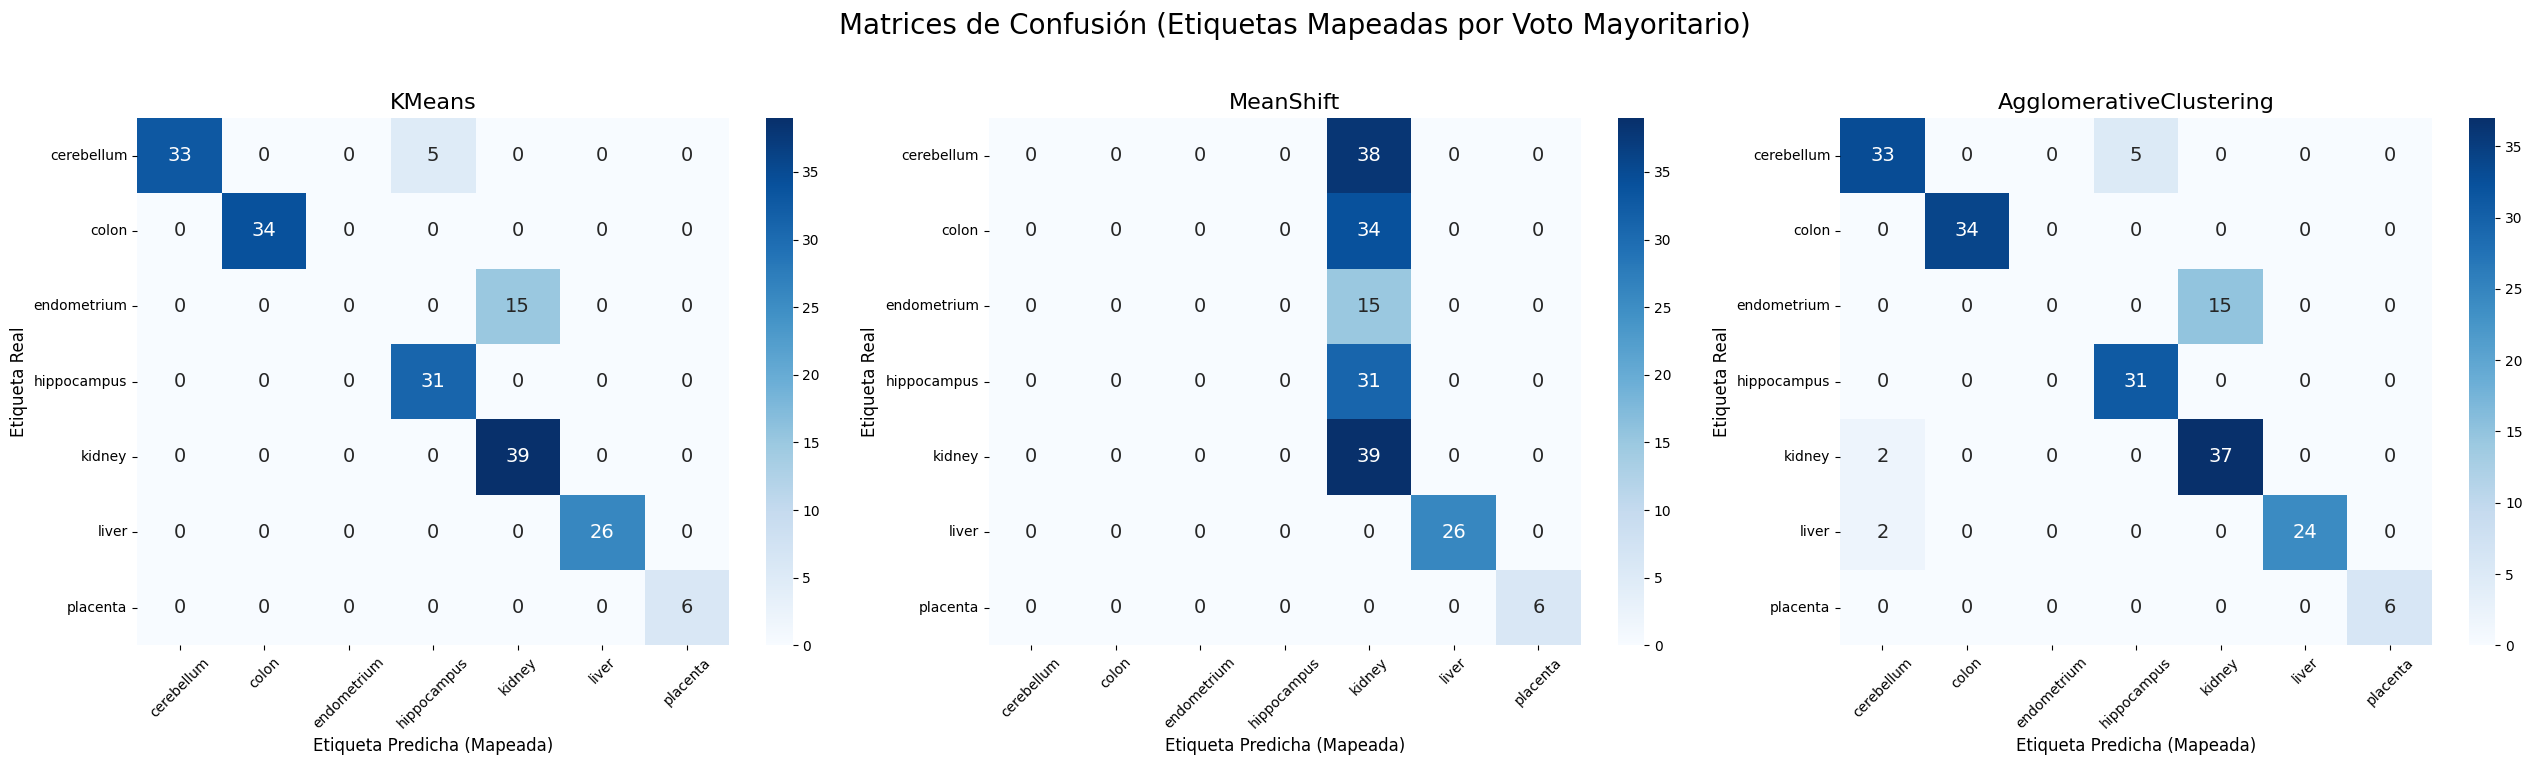

In [48]:
# =======================================================
# 9. ANÁLISIS - MATRICES DE CONFUSIÓN GRÁFICAS
# =======================================================
print("Generando matrices de confusión gráficas...")

# !pip install seaborn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# --- Función para mapear clusters a etiquetas (voto mayoritario) ---
def get_mapped_labels(y_true, y_pred):
    mapping = {}
    for cluster_label in np.unique(y_pred):
        if cluster_label == -1:
            continue
        indices = np.where(y_pred == cluster_label)[0]
        if len(indices) > 0:
            majority_true_label = mode(y_true[indices], keepdims=False)[0]
            mapping[cluster_label] = majority_true_label
    y_pred_mapped = np.array([mapping.get(label, -1) for label in y_pred])
    return y_pred_mapped

# --- Mapear las etiquetas ---
mapped_kmeans = get_mapped_labels(y_true_encoded, kmeans_labels)
mapped_ms = get_mapped_labels(y_true_encoded, ms_labels)
mapped_agg = get_mapped_labels(y_true_encoded, agg_labels)

# --- Nombres de las clases ---
class_names = le.classes_

# --- Crear los gráficos ---
models_data = {
    "KMeans": mapped_kmeans,
    "MeanShift": mapped_ms,
    "AgglomerativeClustering": mapped_agg
}

fig, axes = plt.subplots(1, 3, figsize=(26, 8))
fig.suptitle('Matrices de Confusión (Etiquetas Mapeadas por Voto Mayoritario)', fontsize=20)

for ax, (title, y_pred_mapped) in zip(axes.flatten(), models_data.items()):
    mask = (y_pred_mapped != -1)
    cm = confusion_matrix(y_true_encoded[mask], y_pred_mapped[mask])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax,
                annot_kws={"size": 14})
    
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Etiqueta Predicha (Mapeada)', fontsize=12)
    ax.set_ylabel('Etiqueta Real', fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [49]:

print("\nGenerando visualizaciones 3D interactivas...")
# !pip install plotly
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# --- Gráfico 1: Etiquetas Reales (El que me mostraste) ---
fig1 = go.Figure(data=[go.Scatter3d(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    z=X_tsne[:, 2],
    mode='markers',
    marker=dict(size=5, color=y_true_encoded, colorscale='Viridis', opacity=0.8),
    text=y_true_labels, # Mostrar nombre de la clase
    hoverinfo='text'
)])
fig1.update_layout(title='Visualización t-SNE (3D) - Etiquetas Reales',
                   scene=dict(xaxis_title='t-SNE 1', yaxis_title='t-SNE 2', zaxis_title='t-SNE 3'))

# --- Gráfico 2: Clusters de KMeans (Para comparar) ---
fig2 = go.Figure(data=[go.Scatter3d(
    x=X_tsne[:, 0],
    y=X_tsne[:, 1],
    z=X_tsne[:, 2],
    mode='markers',
    marker=dict(size=5, color=kmeans_labels, colorscale='Plasma', opacity=0.8)
)])
fig2.update_layout(title='Visualización t-SNE (3D) - Clusters de KMeans',
                   scene=dict(xaxis_title='t-SNE 1', yaxis_title='t-SNE 2', zaxis_title='t-SNE 3'))

print("Mostrando gráficos. (Si usas Colab, se mostrarán a continuación)")
fig1.show()
fig2.show()


Generando visualizaciones 3D interactivas...
Mostrando gráficos. (Si usas Colab, se mostrarán a continuación)
